In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\project grad\\marketing-service\\data\\Social_Media_Advertising_Transformed .csv")

def build_inflight_training_features(df):
    rows = []

    SNAPSHOTS = [0.25, 0.5, 0.75]

    for _, r in df.iterrows():
        for t in SNAPSHOTS:
            rows.append({
                
                "time_elapsed_ratio": t,
                "budget_spent_ratio": t * (r["Budget_Spent"] / r["Total_Budget"]),
                "impressions_so_far": t * r["Impressions"],
                "clicks_so_far": t * r["Clicks"],
                "revenue_so_far": t * r["Revenue"],
                "ctr": r["CTR"],
                "cpc": r["CPC"],
                "conversion_rate": r["Conversion_Rate"],
                "target_roi": r["ROI"],
                "target_conversions": r["Conversions"]
            })

    new_df = pd.DataFrame(rows)
    new_df["target_conversions"] = np.log1p(new_df["target_conversions"])

    FEATURES = [
        "time_elapsed_ratio",
        "budget_spent_ratio",
        "impressions_so_far",
        "clicks_so_far",
        "revenue_so_far",
        "ctr",
        "cpc",
        "conversion_rate",
    ]

    X = new_df[FEATURES]
    y_roi = new_df["target_roi"]
    y_conv = new_df["target_conversions"]

    return X, y_roi, y_conv

X, y_roi, y_conv = build_inflight_training_features(df)

viz_df = X.copy()
viz_df["target_roi"] = y_roi
viz_df["target_conversions"] = y_conv

viz_df.head()


,time_elapsed_ratio,budget_spent_ratio,impressions_so_far,clicks_so_far,revenue_so_far,ctr,cpc,conversion_rate,target_roi,target_conversions
0,0.25,0.134395,22833.5,7580.50,13317.48375,33.199,0.378,6.0,3.65,7.506768
1,0.50,0.268790,45667.0,15161.00,26634.96750,33.199,0.378,6.0,3.65,7.506768
2,0.75,0.403185,68500.5,22741.50,39952.45125,33.199,0.378,6.0,3.65,7.506768
3,0.25,0.007490,850.0,158.75,628.75000,18.676,0.787,12.0,4.03,4.346399
4,0.50,0.014979,1700.0,317.50,1257.50000,18.676,0.787,12.0,4.03,4.346399


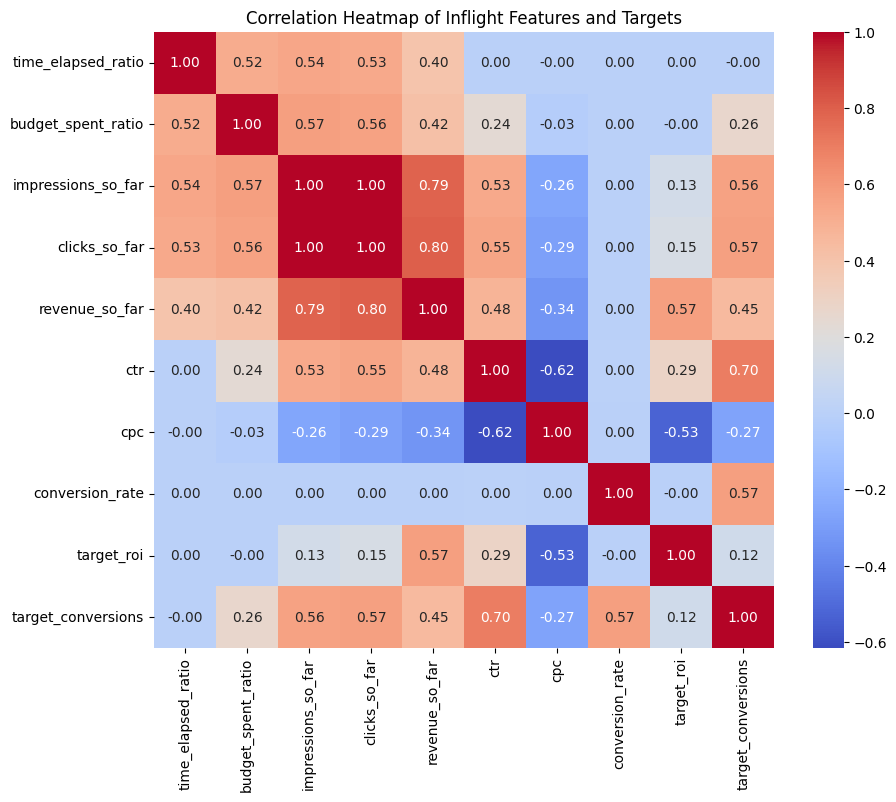

In [3]:
plt.figure(figsize=(10,8))
corr = viz_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Inflight Features and Targets")
plt.show()


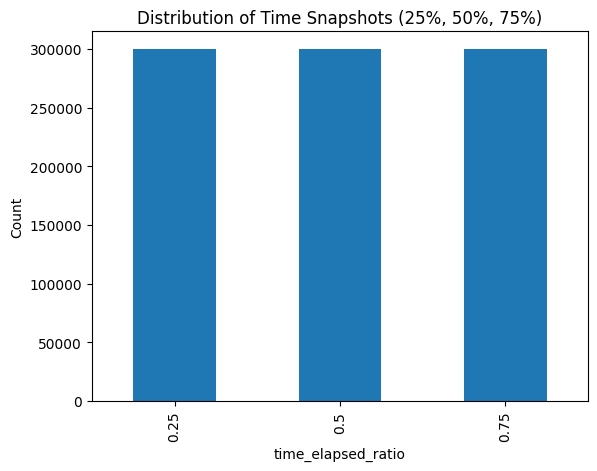

In [5]:
plt.figure()
viz_df["time_elapsed_ratio"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Time Snapshots (25%, 50%, 75%)")
plt.xlabel("time_elapsed_ratio")
plt.ylabel("Count")
plt.show()


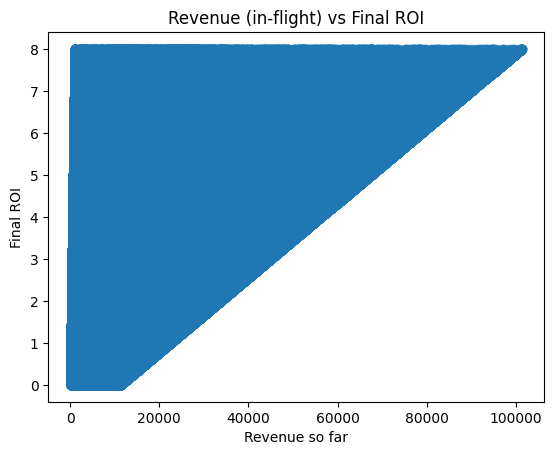

In [7]:
plt.figure()
plt.scatter(viz_df["revenue_so_far"], viz_df["target_roi"], alpha=0.5)
plt.xlabel("Revenue so far")
plt.ylabel("Final ROI")
plt.title("Revenue (in-flight) vs Final ROI")
plt.show()


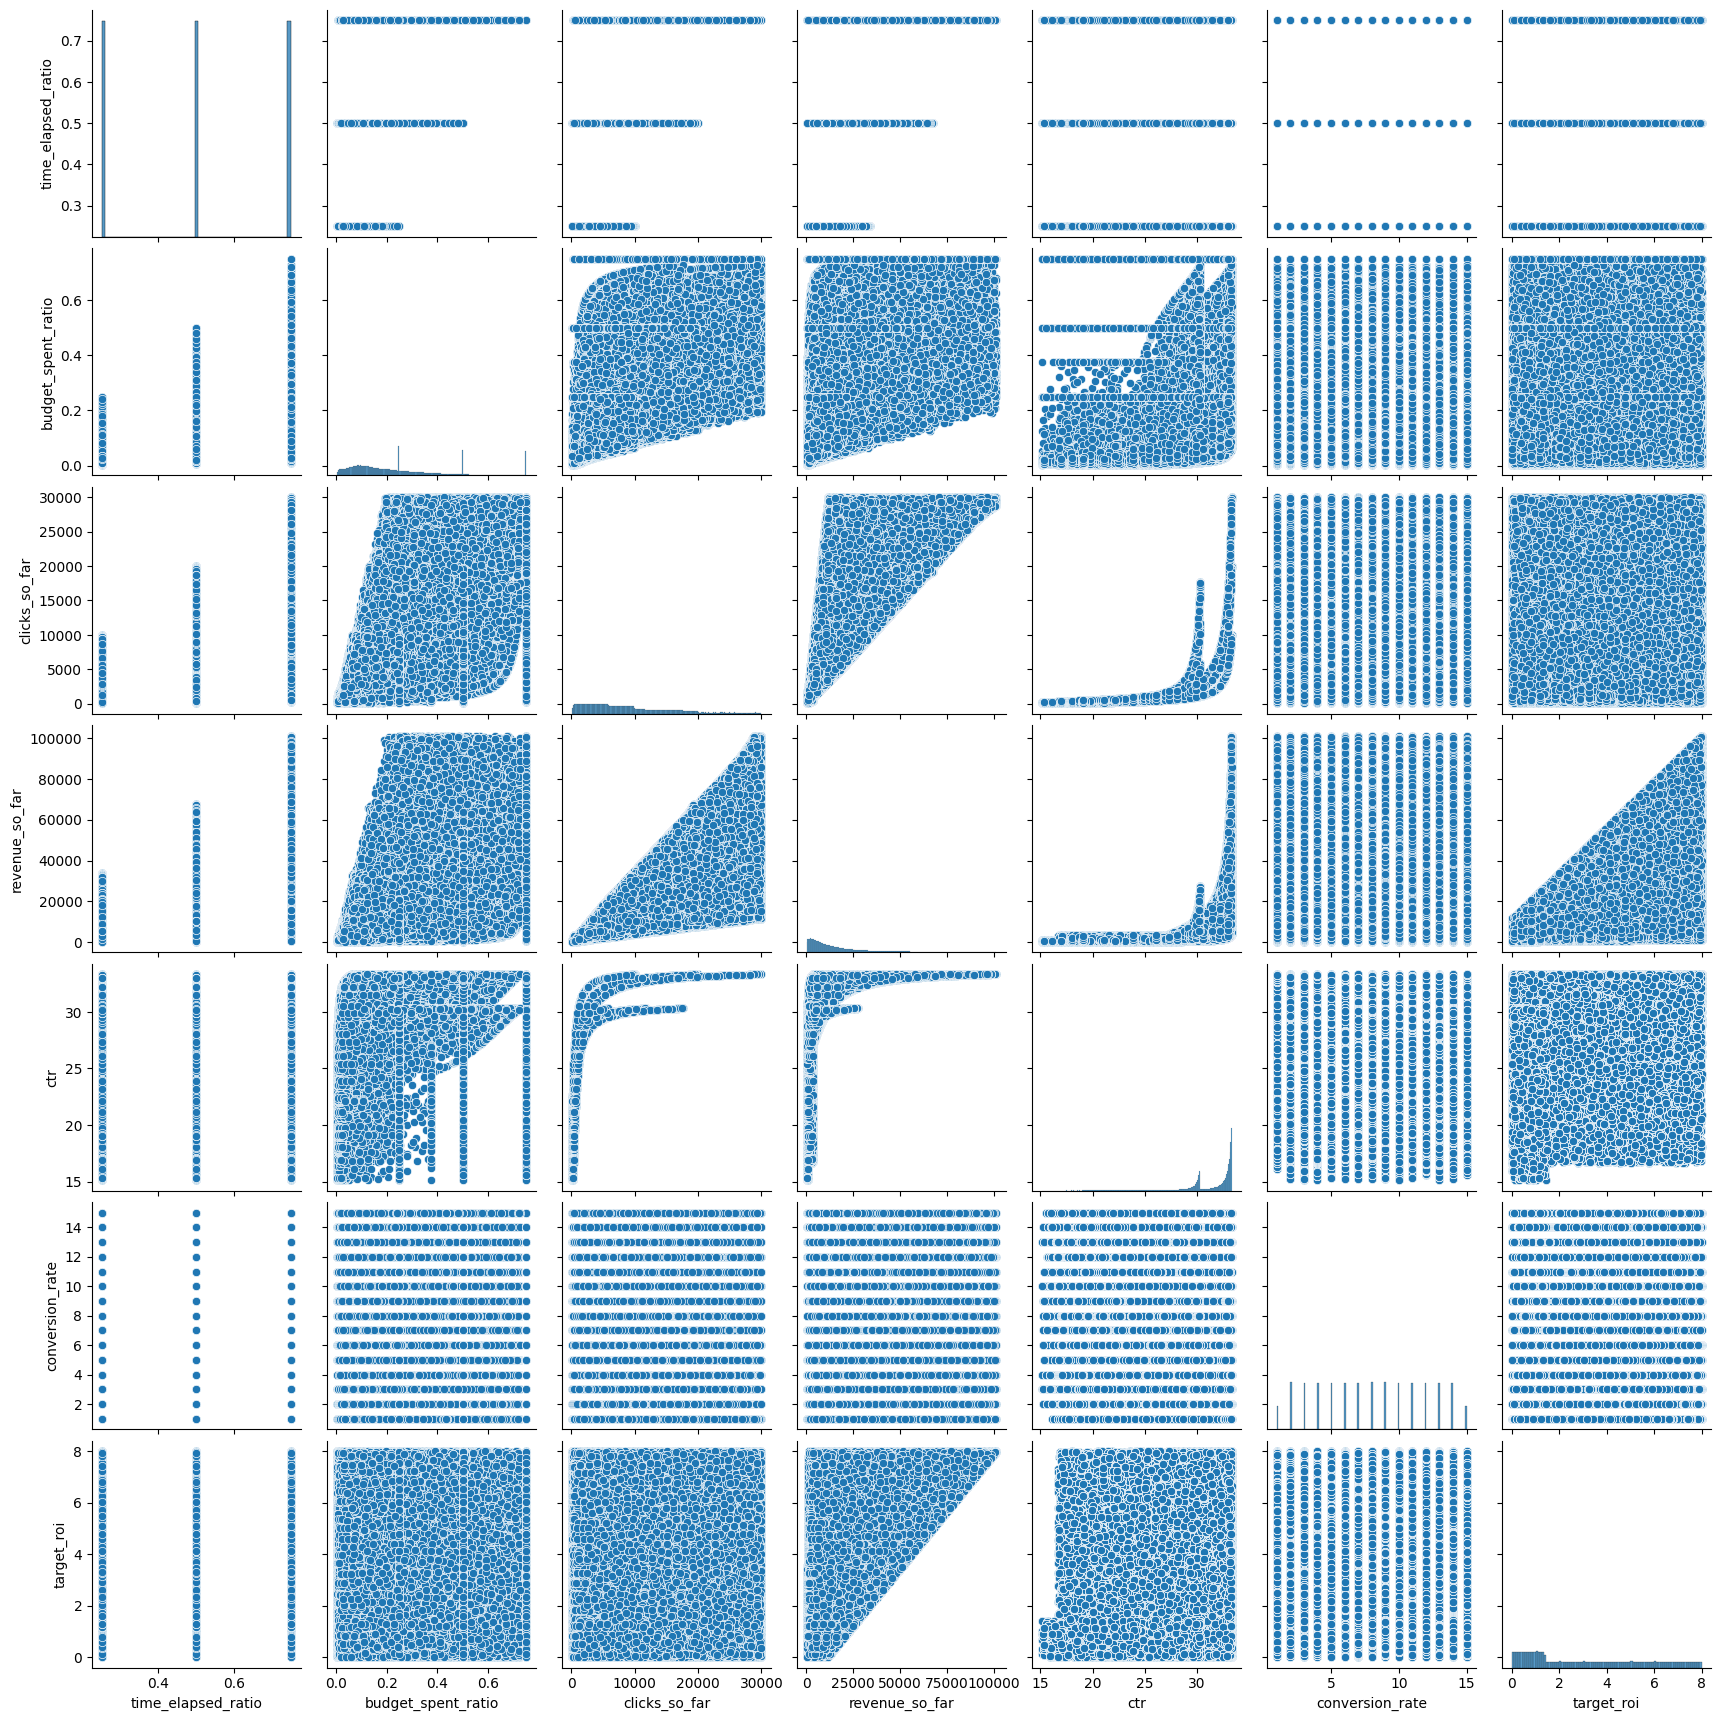

In [8]:
sns.pairplot(viz_df[[
    "time_elapsed_ratio",
    "budget_spent_ratio",
    "clicks_so_far",
    "revenue_so_far",
    "ctr",
    "conversion_rate",
    "target_roi"
]])
plt.show()
